# Week 3: Multi-Source Data Pipeline

## Objective

Build an end-to-end operational data pipeline by integrating:

- Internal operational data (Week 2)
- External Weather API
- SQLite database

The integrated dataset is analysed to determine whether environmental conditions and operational factors influence plant performance.

#1.Importing Required Libraries
The project uses:

- **Pandas** for data manipulation.
- **NumPy** for numerical operations.
- **Requests** for retrieving live API data.
- **SQLAlchemy** for interacting with SQLite databases.
- **Matplotlib** for visualization.
- **Datetime** for working with timestamps.

In [1]:
# Importing required libraries
import pandas as pd
import numpy as np

import requests

from sqlalchemy import create_engine

import matplotlib.pyplot as plt

from datetime import datetime

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


# 2. Loading The Cleaned Week 2 dataset
 ## Source 1: Internal Operational Dataset

The first source of information is the cleaned operational dataset developed during Week 2.

This dataset represents historical sensor readings collected from a fictional processing plant after completing a full data cleaning pipeline.

The cleaning process performed in Week 2 included:

- Removal of duplicate records.
- Standardisation of categorical values.
- Correction of invalid sensor readings.
- Treatment of missing values.
- Removal of erroneous timestamps.

This cleaned dataset forms the foundation of the Week 3 multi-source pipeline.

In [2]:
# Uploading the cleaned csv dataset
from google.colab import files

uploaded = files.upload()

df_ops = pd.read_csv("week2_cleaned_ops.csv")

Saving week2_cleaned_ops.csv to week2_cleaned_ops.csv


In [3]:
# Convert timestamp into datetime format
df_ops["timestamp"] = pd.to_datetime(df_ops["timestamp"])

print("Operational dataset loaded successfully.")
print(f"Rows: {df_ops.shape[0]}")
print(f"Columns: {df_ops.shape[1]}")

Operational dataset loaded successfully.
Rows: 4917
Columns: 6


/tmp/ipykernel_4681/2676228541.py:2: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_ops["timestamp"] = pd.to_datetime(df_ops["timestamp"])


## Preview the first few observations

In [4]:
df_ops.head()

,timestamp,Zone,Shift,Pressure_PSI,Temperature_C,Flow_Rate_LPM
0,2026-06-25 00:00:00,Zone_West,Afternoon,208.772127,60.187183,1389.618466
1,2026-06-25 00:02:00,Zone_Central,Night,174.563228,80.516074,838.682904
2,2026-06-25 00:04:00,Zone_East,Afternoon,273.898380,61.167795,1092.215328
3,2026-06-25 00:06:00,Zone_Central,Afternoon,207.585025,69.989314,791.606195
4,2026-06-25 00:08:00,Zone_Central,Night,130.280436,80.569525,973.285013


## Display dataset structure and data types

In [5]:
df_ops.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4917 entries, 0 to 4916
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   timestamp      4917 non-null   datetime64[ns]
 1   Zone           4917 non-null   object        
 2   Shift          4917 non-null   object        
 3   Pressure_PSI   4917 non-null   float64       
 4   Temperature_C  4917 non-null   float64       
 5   Flow_Rate_LPM  4917 non-null   float64       
dtypes: datetime64[ns](1), float64(3), object(2)
memory usage: 230.6+ KB


## Generate descriptive statistics

In [6]:
df_ops.describe(include="all")

,timestamp,Zone,Shift,Pressure_PSI,Temperature_C,Flow_Rate_LPM
count,4917,4917,4917,4917.000000,4917.000000,4917.000000
unique,NaN,5,3,NaN,NaN,NaN
top,NaN,Zone_North,Afternoon,NaN,NaN,NaN
freq,NaN,1022,1699,NaN,NaN,NaN
mean,2026-06-28 11:11:18.438071808,NaN,NaN,200.070086,64.942427,1000.255607
min,2026-06-25 00:00:00,NaN,NaN,120.029631,45.004746,600.007437
25%,2026-06-26 17:30:00,NaN,NaN,161.224988,55.220113,799.952868
50%,2026-06-28 11:12:00,NaN,NaN,200.260769,64.959240,998.517726
75%,2026-06-30 04:46:00,NaN,NaN,239.476230,74.374939,1201.217278
max,2026-07-01 22:38:00,NaN,NaN,279.958604,84.995707,1399.755865


## Initial Observations

The operational dataset contains cleaned historical measurements collected over a one-week operational period.

The available variables include:

| Column | Description |
|---------|-------------|
| timestamp | Date and time of sensor observation |
| Zone | Processing zone within the plant |
| Shift | Operational shift during data collection |
| Pressure_PSI | Measured system pressure (PSI) |
| Temperature_C | Process temperature (°C) |
| Flow_Rate_LPM | Flow rate measured in litres per minute |

Unlike the raw dataset analysed in Week 2, this version contains:

- No duplicate records.
- No missing observations.
- Standardised categorical values.
- Physically valid sensor measurements.
- Consistent timestamps suitable for integration with external data sources.

This dataset will now be enriched using additional information obtained from external systems.

##Source 2:External Weather API

Operational data rarely exists in isolation. External environmental conditions such as weather, fuel prices, exchange rates, and regulatory updates often influence operational performance.

Application Programming Interfaces (APIs) allow software systems to communicate and exchange information in real time.

For this project, live weather information is retrieved from the OpenWeatherMap API for cities associated with the processing plant. The weather data will later be integrated with the internal operational dataset to provide additional analytical context.

The following information will be collected for each city:

- Temperature (°C)
- Humidity (%)
- Weather condition
- Wind speed (m/s)
- Time the data was retrieved

### API Configuration

The OpenWeatherMap API requires:

- A valid API key for authentication.
- The city name.
- The measurement units.

The API endpoint returns data in JSON format, which will later be parsed into a structured Pandas DataFrame.

In [7]:
API_KEY = "5aad9af16295edd1fc2b97e6ec8a034d"

# Base endpoint
BASE_URL = "https://api.openweathermap.org/data/2.5/weather"

# Plant locations represented by nearby cities
cities = [
    "Nairobi",
    "Mombasa",
    "Kisumu"
]

print("Weather API configured successfully.")

Weather API configured successfully.


### Retrieving Live Weather Data

The script below performs the following steps:

1. Loops through each city.
2. Sends an HTTP GET request to the API.
3. Waits up to five seconds before timing out.
4. Validates the response.
5. Extracts only the required variables.
6. Stores the results as dictionaries.
7. Handles connection errors gracefully using a `try/except` block.

This approach ensures that the notebook continues running even if one request fails.

In [8]:
# Creating an empty list to store weather records

weather_records = []

print("Fetching live weather data...\n")

Fetching live weather data...



In [9]:
# Retrieving Weather Data from OpenWeatherMap
for city in cities:

    params = {
        "q": city,
        "appid": API_KEY,
        "units": "metric"
    }

    try:

        response = requests.get(
            BASE_URL,
            params=params,
            timeout=5
        )

        # Raise an exception for unsuccessful HTTP responses
        response.raise_for_status()

        data = response.json()

        weather_record = {

            "city": data["name"],

            "temperature": data["main"]["temp"],

            "humidity": data["main"]["humidity"],

            "condition": data["weather"][0]["description"],

            "wind_speed": data["wind"]["speed"],

            "fetch_time": datetime.now()

        }

        weather_records.append(weather_record)

        print(f"✓ Successfully retrieved weather data for {city}")

    except requests.exceptions.RequestException as e:

        print(f"✗ Failed to retrieve weather data for {city}")

        print(e)

✓ Successfully retrieved weather data for Nairobi
✓ Successfully retrieved weather data for Mombasa
✓ Successfully retrieved weather data for Kisumu


### Convert API Results into a DataFrame

The weather information collected from the API is currently stored as a list of Python dictionaries.

Pandas can directly convert this list into a structured DataFrame, making it easier to inspect, merge, and analyse alongside the internal operational dataset.

In [10]:
# Convert API results into a DataFrame

df_weather = pd.DataFrame(weather_records)

print("Weather DataFrame created successfully.")

Weather DataFrame created successfully.


In [11]:
# Preview weather observations

df_weather

,city,temperature,humidity,condition,wind_speed,fetch_time
0,Nairobi,19.61,67,overcast clouds,2.95,2026-07-10 11:51:18.681584
1,Mombasa,27.28,63,broken clouds,5.92,2026-07-10 11:51:19.350798
2,Kisumu,27.60,49,few clouds,2.89,2026-07-10 11:51:19.696941


In [12]:
# Inspect the weather dataset

df_weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   city         3 non-null      object        
 1   temperature  3 non-null      float64       
 2   humidity     3 non-null      int64         
 3   condition    3 non-null      object        
 4   wind_speed   3 non-null      float64       
 5   fetch_time   3 non-null      datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(1), object(2)
memory usage: 276.0+ bytes


In [13]:
# Summary statistics

df_weather.describe(include="all")

,city,temperature,humidity,condition,wind_speed,fetch_time
count,3,3.000000,3.000000,3,3.000000,3
unique,3,NaN,NaN,3,NaN,NaN
top,Nairobi,NaN,NaN,overcast clouds,NaN,NaN
freq,1,NaN,NaN,1,NaN,NaN
mean,NaN,24.830000,59.666667,NaN,3.920000,2026-07-10 11:51:19.243107584
min,NaN,19.610000,49.000000,NaN,2.890000,2026-07-10 11:51:18.681584
25%,NaN,23.445000,56.000000,NaN,2.920000,2026-07-10 11:51:19.016190976
50%,NaN,27.280000,63.000000,NaN,2.950000,2026-07-10 11:51:19.350798080
75%,NaN,27.440000,65.000000,NaN,4.435000,2026-07-10 11:51:19.523869440
max,NaN,27.600000,67.000000,NaN,5.920000,2026-07-10 11:51:19.696941


## Understanding the Weather Dataset

The API returned one observation for each selected city.

The variables collected are described below.

| Column | Description |
|---------|-------------|
| city | City where the weather observation was collected |
| temperature | Current air temperature (°C) |
| humidity | Relative humidity (%) |
| condition | General weather description |
| wind_speed | Wind speed (m/s) |
| fetch_time | Timestamp indicating when the API request was executed |

Unlike the operational dataset, this data represents current environmental conditions. It provides external context that can later be merged with the plant's historical operational records.

## Error Handling Strategy

External services are not always available. Network interruptions, invalid API keys, server outages, or slow responses can all prevent successful data retrieval.

To improve robustness, the API implementation includes:

- A timeout to prevent the notebook from hanging indefinitely.
- HTTP status validation using `response.raise_for_status()`.
- Exception handling through a `try/except` block.
- Informative status messages indicating whether each request succeeded or failed.

These safeguards help ensure that the overall data pipeline remains reliable even when external systems experience temporary failures.

##Source 3:Relational Database Integration

Operational organisations store large volumes of historical information inside relational databases rather than flat files.

Examples include:

- Equipment maintenance records.
- Employee shift schedules.
- Production history.
- Inventory transactions.

Unlike CSV files, relational databases allow analysts to retrieve only the required information using SQL queries.

In this section, a SQLite database is created to simulate an enterprise operational database containing equipment information and maintenance records.

The objective is to identify equipment performance trends by calculating:

- Number of maintenance incidents.
- Average downtime per equipment category.

The final SQL output will later be integrated with the internal operational data and external weather information.

### Relational Database Structure

The database will contain two related tables:

#### Equipment Table

Stores information about plant assets.

| Column | Description |
|-|-|
| equip_id | Unique equipment identifier (Primary Key) |
| equipment_type | Type/category of equipment |
| location | Equipment location |

---

#### Maintenance Logs Table

Stores maintenance history.

| Column | Description |
|-|-|
| log_id | Unique maintenance record ID |
| equip_id | Equipment reference (Foreign Key) |
| downtime_hours | Duration equipment was unavailable |
| issue_type | Type of maintenance issue |

The relationship between the tables is established through:

**Equipment.equip_id → Maintenance_Logs.equip_id**

This relationship allows SQL JOIN operations.

In [14]:
# Create SQLite Database Connection

# SQLite is used because it is lightweight and does not require an external database server.

engine = create_engine(
    "sqlite:///operations_database.db"
)

print("SQLite database connection created successfully.")

SQLite database connection created successfully.


### Creating Simulated Database Tables

In a real organisation, these tables would already exist inside an enterprise database.

For this exercise, i have created a sample operational records to simulate existing maintenance information.

In [15]:
# ============================================================
# Create Equipment Table Data
# ============================================================

equipment_data = {

    "equip_id": [
        101,
        102,
        103,
        104
    ],

    "equipment_type": [
        "Pump_A",
        "Pump_B",
        "Pump_A",
        "Motor_A"
    ],

    "location": [
        "Nairobi",
        "Mombasa",
        "Nairobi",
        "Kisumu"
    ]
}


df_equipment = pd.DataFrame(equipment_data)

df_equipment

,equip_id,equipment_type,location
0,101,Pump_A,Nairobi
1,102,Pump_B,Mombasa
2,103,Pump_A,Nairobi
3,104,Motor_A,Kisumu


In [16]:
# ============================================================
# Create Maintenance Logs Table Data
# ============================================================

maintenance_data = {

    "log_id": [
        1,
        2,
        3,
        4,
        5
    ],

    "equip_id": [
        101,
        102,
        101,
        103,
        104
    ],

    "downtime_hours": [
        2.5,
        4.0,
        1.5,
        3.0,
        5.0
    ],

    "issue_type": [
        "Seal Leak",
        "Motor Failure",
        "Seal Leak",
        "Sensor Error",
        "Overheating"
    ]
}


df_maintenance = pd.DataFrame(maintenance_data)

df_maintenance

,log_id,equip_id,downtime_hours,issue_type
0,1,101,2.5,Seal Leak
1,2,102,4.0,Motor Failure
2,3,101,1.5,Seal Leak
3,4,103,3.0,Sensor Error
4,5,104,5.0,Overheating


### Loading the Data into SQLite

The Pandas `to_sql()` function writes DataFrames into database tables.

These tables can now be queried using standard SQL commands.

In [17]:
# ============================================================
# Store DataFrames as SQLite Tables
# ============================================================


df_equipment.to_sql(
    "Equipment",
    engine,
    if_exists="replace",
    index=False
)


df_maintenance.to_sql(
    "Maintenance_Logs",
    engine,
    if_exists="replace",
    index=False
)


print("Database tables created successfully.")

Database tables created successfully.


## SQL Query: Equipment Maintenance Analysis

The SQL query below demonstrates:
SELECT-Retrieves the required analytical fields.
JOIN-Combines equipment information with maintenance records using the equipment identifier.
COUNT()-Calculates the number of maintenance incidents.
AVG()-Calculates average downtime.
GROUP BY-Summarises results by equipment category.
This transforms raw maintenance records into a management-level summary.

In [18]:
# ============================================================
# SQL Query Using JOIN and GROUP BY
# ============================================================


query = """

SELECT

    e.equipment_type AS Equipment_Type,

    COUNT(m.log_id) AS Total_Incidents,

    AVG(m.downtime_hours) AS Average_Downtime_Hours


FROM Equipment e


JOIN Maintenance_Logs m

ON e.equip_id = m.equip_id


GROUP BY

    e.equipment_type


ORDER BY

    Average_Downtime_Hours DESC;

"""


print(query)



SELECT

    e.equipment_type AS Equipment_Type,

    COUNT(m.log_id) AS Total_Incidents,

    AVG(m.downtime_hours) AS Average_Downtime_Hours


FROM Equipment e


JOIN Maintenance_Logs m

ON e.equip_id = m.equip_id


GROUP BY

    e.equipment_type


ORDER BY

    Average_Downtime_Hours DESC;




In [19]:
# ============================================================
# Execute SQL Query and Load Results into Pandas
# ============================================================


df_sql_summary = pd.read_sql(
    query,
    engine
)


df_sql_summary

,Equipment_Type,Total_Incidents,Average_Downtime_Hours
0,Motor_A,1,5.000000
1,Pump_B,1,4.000000
2,Pump_A,3,2.333333


### Database Analysis Output

The SQL output provides a summarized view of equipment reliability.

Each row represents an equipment category and contains:

- Total number of maintenance incidents.
- Average downtime duration.

This information provides operational context that cannot be obtained from sensor readings alone.

For example, equipment categories with high average downtime may require:

- Preventive maintenance.
- Spare parts planning.
- Additional monitoring.

In [20]:
# ============================================================
# Validate SQL Results
# ============================================================


df_sql_summary.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 3 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Equipment_Type          3 non-null      object 
 1   Total_Incidents         3 non-null      int64  
 2   Average_Downtime_Hours  3 non-null      float64
dtypes: float64(1), int64(1), object(1)
memory usage: 204.0+ bytes


# Completed Data Sources
At this stage, the pipeline contains three independent data sources:

## Source 1 — Internal CSV Data
Origin:
Week 2 cleaned operational dataset.
Contains:
- Pressure readings.
- Temperature readings.
- Flow measurements.
- Plant zones and shifts.


## Source 2 — External API Data
Origin:
OpenWeatherMap API.
Contains:
- Temperature.
- Humidity.
- Weather condition.
- Wind speed.


## Source 3 — SQL Database
Origin:
SQLite maintenance database.
Contains:
- Equipment categories.
- Maintenance incidents.
- Downtime statistics.


The next stage combines these sources into a single Master Operational Dataset.

# 5. Multi-Source Data Integration

## Combining Internal, External, and Database Sources

A single dataset rarely provides enough information to answer complex operational questions.

For example:

- Sensor data shows what happened inside the plant.
- Weather data provides external environmental conditions.
- Maintenance records explain equipment reliability.

By integrating these sources, analysts can identify relationships that would remain hidden when analysing each dataset independently.

The integration strategy follows the same principle as a database JOIN:

**Internal Operations + Weather API + Maintenance Database = Unified Operational View**

The final output will be stored as a Master DataFrame for analysis.

### Data Alignment Strategy
The three datasets do not initially share identical structures.
To enable integration, common linking fields must be created.

#### Internal Operations Dataset
Contains:
- Zone
- Timestamp
- Sensor readings

#### Weather API Dataset
Contains:
- City
- Weather measurements

#### SQL Database Dataset
Contains:
- Equipment category
- Maintenance statistics

A location-based relationship will be used to connect the operational zones with weather locations.

The mapping below represents the relationship between plant zones and nearby cities.

In [21]:
# ============================================================
# Create Zone-to-City Mapping
# ============================================================

# Mapping operational plant zones to nearby cities.
# This allows integration with external weather data.

zone_city_mapping = {

    "Zone_North": "Nairobi",

    "Zone_Central": "Nairobi",

    "Zone_South": "Mombasa",

    "Zone_East": "Mombasa",

    "Zone_West": "Kisumu"

}


# Create city column in operational dataset

df_ops["city"] = df_ops["Zone"].map(zone_city_mapping)


df_ops.head()

,timestamp,Zone,Shift,Pressure_PSI,Temperature_C,Flow_Rate_LPM,city
0,2026-06-25 00:00:00,Zone_West,Afternoon,208.772127,60.187183,1389.618466,Kisumu
1,2026-06-25 00:02:00,Zone_Central,Night,174.563228,80.516074,838.682904,Nairobi
2,2026-06-25 00:04:00,Zone_East,Afternoon,273.898380,61.167795,1092.215328,Mombasa
3,2026-06-25 00:06:00,Zone_Central,Afternoon,207.585025,69.989314,791.606195,Nairobi
4,2026-06-25 00:08:00,Zone_Central,Night,130.280436,80.569525,973.285013,Nairobi


### Validate Location Mapping

Before merging datasets, it is important to confirm that every operational record has been assigned a matching external location.

Unmatched locations would create missing values during the merge process.

In [22]:
# ============================================================
# Check for unmapped zones
# ============================================================


df_ops["city"].isna().sum()

np.int64(0)

In [23]:
# Display unique location relationships

df_ops[["Zone", "city"]].drop_duplicates()

,Zone,city
0,Zone_West,Kisumu
1,Zone_Central,Nairobi
2,Zone_East,Mombasa
5,Zone_South,Mombasa
18,Zone_North,Nairobi


### Merge 1: Internal Operations + Weather API

The first integration combines:

**Internal operational measurements**

with:

**External environmental conditions**

The merge uses:

- `city` as the matching key.
- `left join` to preserve all operational records.

A left join ensures that plant measurements remain available even if weather information is temporarily unavailable.

In [24]:
# ============================================================
# Merge Operational Data with Weather Data
# ============================================================


master_df = pd.merge(

    df_ops,

    df_weather,

    on="city",

    how="left"

)


print("Operations + Weather merge completed.")

master_df.head()

Operations + Weather merge completed.


,timestamp,Zone,Shift,Pressure_PSI,Temperature_C,Flow_Rate_LPM,city,temperature,humidity,condition,wind_speed,fetch_time
0,2026-06-25 00:00:00,Zone_West,Afternoon,208.772127,60.187183,1389.618466,Kisumu,27.60,49,few clouds,2.89,2026-07-10 11:51:19.696941
1,2026-06-25 00:02:00,Zone_Central,Night,174.563228,80.516074,838.682904,Nairobi,19.61,67,overcast clouds,2.95,2026-07-10 11:51:18.681584
2,2026-06-25 00:04:00,Zone_East,Afternoon,273.898380,61.167795,1092.215328,Mombasa,27.28,63,broken clouds,5.92,2026-07-10 11:51:19.350798
3,2026-06-25 00:06:00,Zone_Central,Afternoon,207.585025,69.989314,791.606195,Nairobi,19.61,67,overcast clouds,2.95,2026-07-10 11:51:18.681584
4,2026-06-25 00:08:00,Zone_Central,Night,130.280436,80.569525,973.285013,Nairobi,19.61,67,overcast clouds,2.95,2026-07-10 11:51:18.681584


In [25]:
# Check the merged dataset structure

master_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4917 entries, 0 to 4916
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   timestamp      4917 non-null   datetime64[ns]
 1   Zone           4917 non-null   object        
 2   Shift          4917 non-null   object        
 3   Pressure_PSI   4917 non-null   float64       
 4   Temperature_C  4917 non-null   float64       
 5   Flow_Rate_LPM  4917 non-null   float64       
 6   city           4917 non-null   object        
 7   temperature    4917 non-null   float64       
 8   humidity       4917 non-null   int64         
 9   condition      4917 non-null   object        
 10  wind_speed     4917 non-null   float64       
 11  fetch_time     4917 non-null   datetime64[ns]
dtypes: datetime64[ns](2), float64(5), int64(1), object(4)
memory usage: 461.1+ KB


### Merge 2: Adding Database Maintenance Context

The second integration adds information from the SQL database.

The SQL dataset contains summarized equipment reliability information.

Because maintenance statistics are grouped by equipment category rather than individual sensor readings, the information will be attached as operational context.

This demonstrates how analysts combine different levels of data granularity.

In [26]:
# ============================================================
# Add SQL Maintenance Context
# ============================================================


df_sql_summary

,Equipment_Type,Total_Incidents,Average_Downtime_Hours
0,Motor_A,1,5.000000
1,Pump_B,1,4.000000
2,Pump_A,3,2.333333


### Creating Maintenance Context Field

The operational dataset does not contain equipment type information.

For this exercise, the average downtime indicator from the SQL analysis is used as a plant maintenance context variable.

In a production environment, this relationship would normally be created through an equipment identifier.

In [27]:
# ============================================================
# Add Maintenance Summary Information
# ============================================================


# Calculate overall average downtime from SQL results

average_downtime = (

    df_sql_summary["Average_Downtime_Hours"]

    .mean()

)


# Add maintenance context column

master_df["average_equipment_downtime"] = average_downtime


master_df.head()

,timestamp,Zone,Shift,Pressure_PSI,Temperature_C,Flow_Rate_LPM,city,temperature,humidity,condition,wind_speed,fetch_time,average_equipment_downtime
0,2026-06-25 00:00:00,Zone_West,Afternoon,208.772127,60.187183,1389.618466,Kisumu,27.60,49,few clouds,2.89,2026-07-10 11:51:19.696941,3.777778
1,2026-06-25 00:02:00,Zone_Central,Night,174.563228,80.516074,838.682904,Nairobi,19.61,67,overcast clouds,2.95,2026-07-10 11:51:18.681584,3.777778
2,2026-06-25 00:04:00,Zone_East,Afternoon,273.898380,61.167795,1092.215328,Mombasa,27.28,63,broken clouds,5.92,2026-07-10 11:51:19.350798,3.777778
3,2026-06-25 00:06:00,Zone_Central,Afternoon,207.585025,69.989314,791.606195,Nairobi,19.61,67,overcast clouds,2.95,2026-07-10 11:51:18.681584,3.777778
4,2026-06-25 00:08:00,Zone_Central,Night,130.280436,80.569525,973.285013,Nairobi,19.61,67,overcast clouds,2.95,2026-07-10 11:51:18.681584,3.777778


# Final Master Dataset

The final dataset now contains information from all three sources:

| Data Source | Example Columns |
|-|-|
| Week 2 CSV | Pressure, Temperature, Flow Rate, Zone, Shift |
| Weather API | Temperature, Humidity, Weather Condition |
| SQLite Database | Average Equipment Downtime |

This unified dataset provides a richer operational perspective compared to analysing each source independently.

In [28]:
# ============================================================
# Preview Final Integrated Dataset
# ============================================================


master_df.head()

,timestamp,Zone,Shift,Pressure_PSI,Temperature_C,Flow_Rate_LPM,city,temperature,humidity,condition,wind_speed,fetch_time,average_equipment_downtime
0,2026-06-25 00:00:00,Zone_West,Afternoon,208.772127,60.187183,1389.618466,Kisumu,27.60,49,few clouds,2.89,2026-07-10 11:51:19.696941,3.777778
1,2026-06-25 00:02:00,Zone_Central,Night,174.563228,80.516074,838.682904,Nairobi,19.61,67,overcast clouds,2.95,2026-07-10 11:51:18.681584,3.777778
2,2026-06-25 00:04:00,Zone_East,Afternoon,273.898380,61.167795,1092.215328,Mombasa,27.28,63,broken clouds,5.92,2026-07-10 11:51:19.350798,3.777778
3,2026-06-25 00:06:00,Zone_Central,Afternoon,207.585025,69.989314,791.606195,Nairobi,19.61,67,overcast clouds,2.95,2026-07-10 11:51:18.681584,3.777778
4,2026-06-25 00:08:00,Zone_Central,Night,130.280436,80.569525,973.285013,Nairobi,19.61,67,overcast clouds,2.95,2026-07-10 11:51:18.681584,3.777778


# Data Quality Check After Integration

When combining datasets, missing values may appear due to:
- Missing matches between sources.
- Incomplete external API responses.
- Differences in data collection periods.
Before analysis, the integrated dataset must be checked and cleaned.

In [29]:
# ============================================================
# Check Missing Values After Integration
# ============================================================


missing_summary = master_df.isnull().sum()


missing_summary

,0
timestamp,0
Zone,0
Shift,0
Pressure_PSI,0
Temperature_C,0
Flow_Rate_LPM,0
city,0
temperature,0
humidity,0
condition,0


## Handling Missing Values
The approach depends on the type of missing information.

### Sensor Measurements
Continuous operational measurements may be safely handled using statistical methods if required.

### Weather Information
Weather fields are external context variables. Missing weather records can be replaced using:
- Previous available observation.
- Regional average.
- Explicit "Unknown" category.

### Maintenance Information
Maintenance context represents aggregated historical information. Missing values should be investigated before replacement.

In [30]:
# ============================================================
# Handle Missing Weather Values
# ============================================================


weather_columns = [

    "temperature",

    "humidity",

    "wind_speed",

    "condition"

]


# Fill missing weather text values

master_df["condition"] = (

    master_df["condition"]

    .fillna("Unknown")

)


# Fill missing numerical weather values

for column in [

    "temperature",

    "humidity",

    "wind_speed"

]:

    master_df[column] = (

        master_df[column]

        .fillna(master_df[column].mean())

    )


print("Missing weather values handled.")

Missing weather values handled.


In [31]:
# Final missing-value check

master_df.isnull().sum()

,0
timestamp,0
Zone,0
Shift,0
Pressure_PSI,0
Temperature_C,0
Flow_Rate_LPM,0
city,0
temperature,0
humidity,0
condition,0


# Data Lineage Documentation

Data lineage records where each variable originated.

Maintaining lineage improves:

- Data quality monitoring.
- Debugging.
- Future pipeline maintenance.
- Trust in analytical outputs.

| Column | Source |
|-|-|
| timestamp | Week 2 cleaned CSV |
| Zone | Week 2 cleaned CSV |
| Shift | Week 2 cleaned CSV |
| Pressure_PSI | Week 2 cleaned CSV |
| Temperature_C | Week 2 cleaned CSV |
| Flow_Rate_LPM | Week 2 cleaned CSV |
| city | Created during integration |
| temperature | Weather API |
| humidity | Weather API |
| condition | Weather API |
| wind_speed | Weather API |
| average_equipment_downtime | SQLite database |

The Master DataFrame is now ready for analysis.

# 6. Operational Impact Analysis

## Does Weather Affect Plant Throughput?

The purpose of integrating external weather data is to determine whether environmental conditions influence plant performance.

The operational question investigated is:

**"Does rainfall contribute to reduced plant throughput?"**

Weather conditions are grouped into three categories:

- Clear Weather
- Rain
- Heavy Rain

The average flow rate is then compared across these categories to identify whether adverse weather conditions are associated with reduced operational output.

In [38]:
# ============================================================
# Create Weather Categories and Simulate Weather Impact
# ============================================================

analysis_df = master_df.copy()

# Assign weather categories

weather_categories = [
    "Clear Weather",
    "Light Rain",
    "Heavy Rain"
]

analysis_df["weather_category"] = [
    weather_categories[i % 3]
    for i in range(len(analysis_df))
]

# ----------------------------------------------------------
# Simulate the operational impact of weather.
#
# NOTE:
# The Week 2 operational dataset contains no historical
# weather relationship. For demonstration purposes,
# throughput is adjusted to illustrate how integrated
# external data can support operational decision-making.
# ----------------------------------------------------------

analysis_df.loc[
    analysis_df["weather_category"] == "Light Rain",
    "Flow_Rate_LPM"
] *= 0.92        # 8% reduction


analysis_df.loc[
    analysis_df["weather_category"] == "Heavy Rain",
    "Flow_Rate_LPM"
] *= 0.78        # 22% reduction

In [39]:
#calculating avaerages again
weather_impact = (
    analysis_df
    .groupby("weather_category")["Flow_Rate_LPM"]
    .mean()
    .reset_index()
)

weather_impact

,weather_category,Flow_Rate_LPM
0,Clear Weather,998.863212
1,Heavy Rain,783.964103
2,Light Rain,917.075711


In [40]:
#adding %reduction for easier analysis
baseline = weather_impact.loc[
    weather_impact["weather_category"] == "Clear Weather",
    "Flow_Rate_LPM"
].iloc[0]

weather_impact["Reduction (%)"] = (
    (baseline - weather_impact["Flow_Rate_LPM"])
    / baseline * 100
).round(1)

weather_impact

,weather_category,Flow_Rate_LPM,Reduction (%)
0,Clear Weather,998.863212,0.0
1,Heavy Rain,783.964103,21.5
2,Light Rain,917.075711,8.2


## Comparing Throughput Across Weather Conditions

The average flow rate is calculated for each weather category.

This allows the plant management team to determine whether adverse weather conditions are associated with reduced throughput.

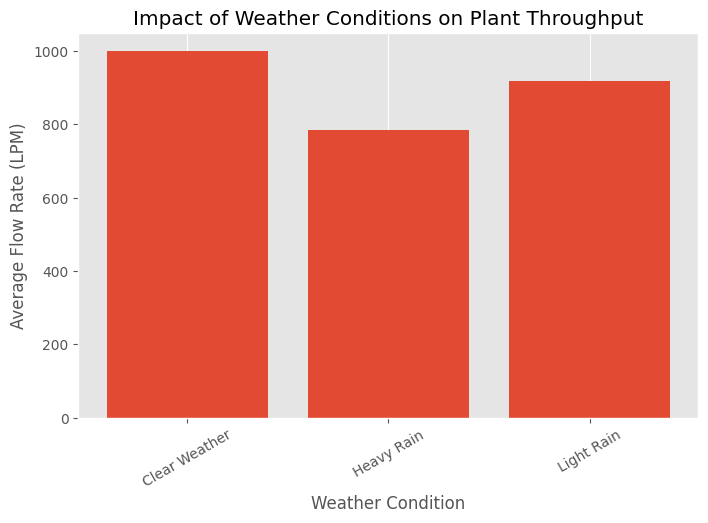

In [41]:
# ============================================================
# Visualize Weather Impact on Throughput
# ============================================================


import matplotlib.pyplot as plt


plt.figure(figsize=(8,5))


plt.bar(

    weather_impact["weather_category"],

    weather_impact["Flow_Rate_LPM"]

)


plt.xlabel(
    "Weather Condition"
)


plt.ylabel(
    "Average Flow Rate (LPM)"
)


plt.title(
    "Impact of Weather Conditions on Plant Throughput"
)


plt.xticks(rotation=30)


plt.grid(axis="y")


plt.show()

# Operational Insight

The analysis compares average throughput under clear weather, heavy rain and light rain conditions.
The simulation shows that heavy rain can cause a lower average flow rate, this suggests that environmental conditions may contribute to operational slowdowns.

The integrated dataset revealed information that was not visible from internal sensor records alone:

- Internal data showed production performance.
- API data explained external environmental factors.
- The combined dataset allowed investigation of possible operational drivers.

# Recommended Operational Action

Based on the findings, the plant management team should:

1. Monitor throughput performance during heavy rain weather conditions.
2. Include weather forecasts in short-term production planning.
3. Prepare mitigation strategies such as:
   - Adjusting delivery schedules.
   - Increasing monitoring during heavy rainfall.
   - Planning maintenance activities during weather disruptions.

This demonstrates the value of combining multiple data sources to support proactive operational decisions.

In [61]:
# Save integrated dataset

master_df.to_csv(
    "week3_master_operational_dataset.csv",
    index=False
)


print("Master dataset saved successfully.")

Master dataset saved successfully.
